# Question 1: Regression Analysis & Data Preprocessing – California Housing Prices

**Scenario:** As a data analyst for a real estate team, we predict `median_house_value` of California census block groups using a **Multiple Linear Regression (MLR)** model.

**Dataset:** [California Housing Prices (Kaggle)](https://www.kaggle.com/datasets/camnugent/california-housing-prices) – 20,640 block groups, 9 numeric features + 1 categorical (`ocean_proximity`).

**Notebook outline**
1. Load data
2. Exploratory Data Analysis (EDA)
3. Preprocessing (missing values, encoding, scaling)
4. Multiple Linear Regression
5. Interpreting coefficients
6. Evaluation (R², MSE, residual analysis)
7. Assumptions of linear regression – stated and verified

In [1]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42

## 1. Load the data
Put Kaggle's `housing.csv` next to this notebook. If it isn't found, the same file is fetched from a public GitHub mirror.

In [2]:
URL = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
path = next((p for p in ["housing.csv", "data/housing.csv"] if os.path.exists(p)), URL)
df = pd.read_csv(path)
print("Loaded from:", path)
df.head()

Loaded from: housing.csv


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,"452,600.0000",NEAR BAY
1,-122.2200,37.8600,21.0000,"7,099.0000","1,106.0000","2,401.0000","1,138.0000",8.3014,"358,500.0000",NEAR BAY
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,"352,100.0000",NEAR BAY
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,"341,300.0000",NEAR BAY
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,"342,200.0000",NEAR BAY


## 2. Exploratory Data Analysis

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,"20,640.0000",-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
latitude,"20,640.0000",35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
housing_median_age,"20,640.0000",28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
total_rooms,"20,640.0000","2,635.7631","2,181.6153",2.0000,"1,447.7500","2,127.0000","3,148.0000","39,320.0000"
total_bedrooms,"20,433.0000",537.8706,421.3851,1.0000,296.0000,435.0000,647.0000,"6,445.0000"
population,"20,640.0000","1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000"
households,"20,640.0000",499.5397,382.3298,1.0000,280.0000,409.0000,605.0000,"6,082.0000"
median_income,"20,640.0000",3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
median_house_value,"20,640.0000","206,855.8169","115,395.6159","14,999.0000","119,600.0000","179,700.0000","264,725.0000","500,001.0000"


In [5]:
# Missing values & duplicates
miss = df.isna().sum().to_frame("missing"); miss["pct"] = miss["missing"] / len(df) * 100
print(miss[miss.missing > 0])
print("Duplicate rows:", df.duplicated().sum())
print("\nocean_proximity counts:\n", df["ocean_proximity"].value_counts())

                missing    pct
total_bedrooms      207 1.0029
Duplicate rows: 0

ocean_proximity counts:
 ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


**Observation:** only `total_bedrooms` has missing values (~1%). Also note `median_house_value` and `housing_median_age` look *capped* (max 500,001 and 52) – checked below.

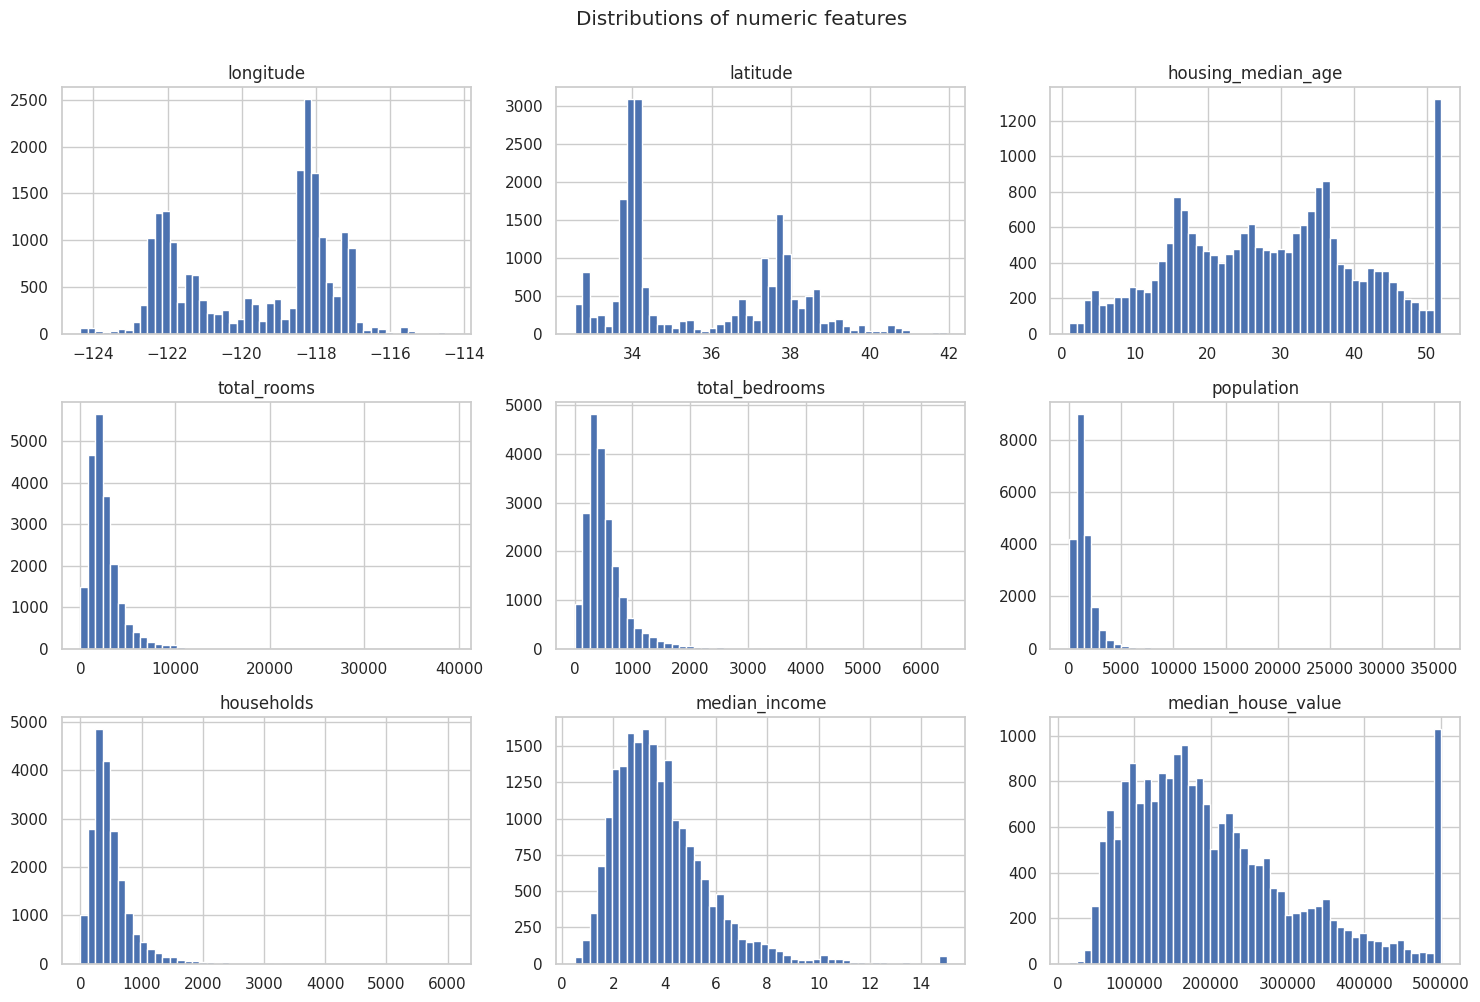

Rows with house value == cap (500001): 965
Rows with housing_median_age == 52  : 1273


In [6]:
num_cols = df.select_dtypes("number").columns
df[num_cols].hist(bins=50, figsize=(15, 10)); plt.suptitle("Distributions of numeric features", y=1.0); plt.tight_layout(); plt.show()
print("Rows with house value == cap (500001):", (df.median_house_value >= 500001).sum())
print("Rows with housing_median_age == 52  :", (df.housing_median_age == 52).sum())

**Observations**
- `total_rooms`, `total_bedrooms`, `population`, `households` are heavily right-skewed (a few very large block groups).
- The target is **censored at $500,001** – a block of rows whose true value is unknown (≥ $500k). A linear model will under-predict these.

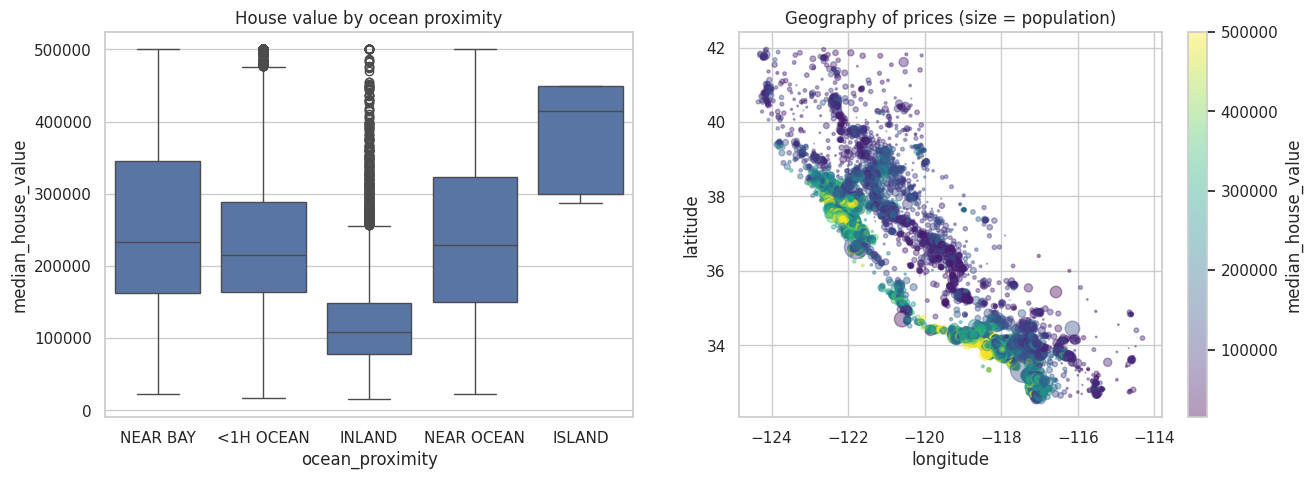

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", ax=ax[0]); ax[0].set_title("House value by ocean proximity")
sc = ax[1].scatter(df.longitude, df.latitude, c=df.median_house_value, s=df.population/100, cmap="viridis", alpha=.4)
plt.colorbar(sc, ax=ax[1], label="median_house_value"); ax[1].set_xlabel("longitude"); ax[1].set_ylabel("latitude"); ax[1].set_title("Geography of prices (size = population)")
plt.show()

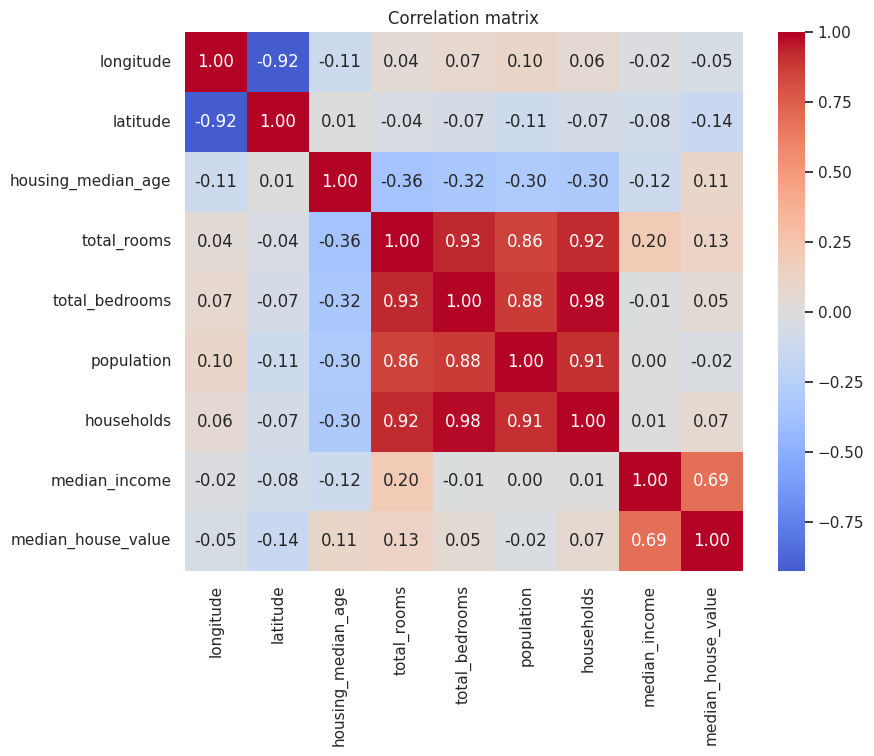

median_house_value    1.0000
median_income         0.6881
total_rooms           0.1342
housing_median_age    0.1056
households            0.0658
total_bedrooms        0.0497
population           -0.0246
longitude            -0.0460
latitude             -0.1442
Name: median_house_value, dtype: float64


In [8]:
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0); plt.title("Correlation matrix"); plt.show()
print(corr["median_house_value"].sort_values(ascending=False))

**Observations**
- `median_income` is by far the strongest correlate of price (~0.69).
- `total_rooms`, `total_bedrooms`, `population`, `households` are very highly inter-correlated (≈0.9+) → **multicollinearity risk**; raw counts mostly measure *block size*. Per-household ratios are more meaningful.
- Latitude/longitude are strongly (negatively) correlated with each other because the state is a diagonal strip.

## 3. Data Preprocessing

| Step | Decision |
|---|---|
| Missing values | Median imputation of `total_bedrooms` (skewed → median is robust). **Fitted on training data only** to avoid leakage. |
| Censored target | Rows with value = 500,001 are **removed** (true value unknown; they would distort the slope). |
| Feature engineering | `rooms_per_household`, `bedrooms_per_room`, `population_per_household` replace the raw, collinear count columns. |
| Encoding | `ocean_proximity` is nominal → **one-hot encoding**, dropping one category (`<1H OCEAN`) as the baseline to avoid the dummy-variable trap. |
| Scaling | `StandardScaler` (fit on train only) so coefficients are comparable; OLS predictions are unaffected by scaling. |

In [9]:
data = df[df.median_house_value < 500001].copy()
print("Rows after removing censored target:", len(data), f"(removed {len(df)-len(data)})")

# Feature engineering
data["rooms_per_household"]      = data.total_rooms / data.households
data["bedrooms_per_room"]        = data.total_bedrooms / data.total_rooms   # NaN where total_bedrooms is NaN
data["population_per_household"] = data.population / data.households
data = data.drop(columns=["total_rooms", "total_bedrooms", "population", "households"])

# Encoding (baseline category = '<1H OCEAN')
data = pd.get_dummies(data, columns=["ocean_proximity"], drop_first=False)
data = data.drop(columns="ocean_proximity_<1H OCEAN")
dummy_cols = [c for c in data.columns if c.startswith("ocean_proximity_")]
data[dummy_cols] = data[dummy_cols].astype(int)

X = data.drop(columns="median_house_value"); y = data["median_house_value"]
print("Missing before imputation:", X.isna().sum()[X.isna().sum() > 0].to_dict())
X.head()

Rows after removing censored target: 19675 (removed 965)
Missing before imputation: {'bedrooms_per_room': 200}


,longitude,latitude,housing_median_age,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.2300,37.8800,41.0000,8.3252,6.9841,0.1466,2.5556,0,0,1,0
1,-122.2200,37.8600,21.0000,8.3014,6.2381,0.1558,2.1098,0,0,1,0
2,-122.2400,37.8500,52.0000,7.2574,8.2881,0.1295,2.8023,0,0,1,0
3,-122.2500,37.8500,52.0000,5.6431,5.8174,0.1845,2.5479,0,0,1,0
4,-122.2500,37.8500,52.0000,3.8462,6.2819,0.1721,2.1815,0,0,1,0


In [10]:
# Train / test split BEFORE fitting imputer / scaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

imputer = SimpleImputer(strategy="median").fit(X_train)
X_train_i = pd.DataFrame(imputer.transform(X_train), columns=X.columns, index=X_train.index)
X_test_i  = pd.DataFrame(imputer.transform(X_test),  columns=X.columns, index=X_test.index)

# Scale only the continuous columns (leave 0/1 dummies as-is so they stay interpretable)
cont_cols = [c for c in X.columns if c not in dummy_cols]
scaler = StandardScaler().fit(X_train_i[cont_cols])
X_train_s, X_test_s = X_train_i.copy(), X_test_i.copy()
X_train_s[cont_cols] = scaler.transform(X_train_i[cont_cols])
X_test_s[cont_cols]  = scaler.transform(X_test_i[cont_cols])
print("Missing after imputation:", int(X_train_s.isna().sum().sum() + X_test_s.isna().sum().sum()))
print("Train:", X_train_s.shape, "Test:", X_test_s.shape)
X_train_s[cont_cols].describe().T[["mean", "std"]]

Missing after imputation: 0
Train: (15740, 11) Test: (3935, 11)


,mean,std
longitude,-0.0000,1.0000
latitude,0.0000,1.0000
housing_median_age,-0.0000,1.0000
median_income,0.0000,1.0000
rooms_per_household,0.0000,1.0000
bedrooms_per_room,0.0000,1.0000
population_per_household,0.0000,1.0000


## 4. Multiple Linear Regression

In [11]:
lr = LinearRegression().fit(X_train_s, y_train)
y_pred_train, y_pred = lr.predict(X_train_s), lr.predict(X_test_s)
print("Intercept:", round(lr.intercept_, 2))

Intercept: 203016.11


## 5. Interpreting the coefficients
Two views:
- **Standardised** coefficient – change in price (\$) for a **1-standard-deviation** increase in the feature → shows *relative importance*.
- **Original-units** coefficient = standardised coef ÷ feature std. dev. → change in price (\$) for **one unit** increase, holding other variables constant.
Dummy variables are interpreted relative to the baseline category `<1H OCEAN`.

In [12]:
coef = pd.DataFrame({"feature": X.columns, "coef_per_1SD": lr.coef_})
scale_map = dict(zip(cont_cols, scaler.scale_))
coef["coef_per_1_unit"] = [c / scale_map[f] if f in scale_map else c for f, c in zip(coef.feature, coef.coef_per_1SD)]
coef = coef.sort_values("coef_per_1SD", key=abs, ascending=False).reset_index(drop=True)
coef

,feature,coef_per_1SD,coef_per_1_unit
0,ocean_proximity_ISLAND,"188,136.1661","188,136.1661"
1,median_income,"65,257.7859","41,679.6785"
2,longitude,"-47,981.3460","-23,944.2961"
3,latitude,"-45,772.3204","-21,288.7914"
4,ocean_proximity_INLAND,"-35,463.1731","-35,463.1731"
5,bedrooms_per_room,"16,700.2266","293,805.8721"
6,housing_median_age,"9,408.5662",750.0556
7,ocean_proximity_NEAR OCEAN,"8,728.6265","8,728.6265"
8,rooms_per_household,"5,693.0830","2,391.1322"
9,population_per_household,"-3,599.7053",-303.0454


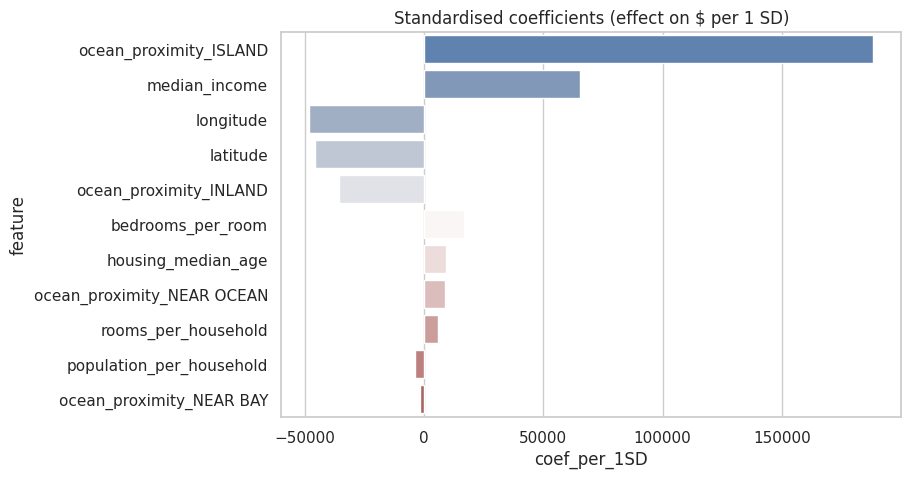

- median_income: +41,680 dollars per +1.0 in median_income (i.e. +$10,000 block-group income)
- housing_median_age: +750 dollars per +1 year of median building age
- rooms_per_household: +2,391 dollars per +1 room per household
- population_per_household: -303 dollars per +1 person per household
- latitude: -21,289 dollars per +1 degree latitude (moving north)
- longitude: -23,944 dollars per +1 degree longitude (moving east)
- ocean_proximity_INLAND: -35,463 dollars per block group vs. <1H OCEAN (baseline)
- ocean_proximity_ISLAND: +188,136 dollars per block group vs. <1H OCEAN (baseline)
- ocean_proximity_NEAR BAY: -1,774 dollars per block group vs. <1H OCEAN (baseline)
- ocean_proximity_NEAR OCEAN: +8,729 dollars per block group vs. <1H OCEAN (baseline)


In [13]:
plt.figure(figsize=(8, 5)); sns.barplot(data=coef, y="feature", x="coef_per_1SD", palette="vlag")
plt.title("Standardised coefficients (effect on $ per 1 SD)"); plt.show()

def show(f, unit_text):
    v = coef.loc[coef.feature == f, "coef_per_1_unit"].iloc[0]
    print(f"- {f}: {v:+,.0f} dollars per {unit_text}")
show("median_income", "+1.0 in median_income (i.e. +$10,000 block-group income)")
show("housing_median_age", "+1 year of median building age")
show("rooms_per_household", "+1 room per household")
show("population_per_household", "+1 person per household")
show("latitude", "+1 degree latitude (moving north)")
show("longitude", "+1 degree longitude (moving east)")
for f in dummy_cols: show(f, "block group vs. <1H OCEAN (baseline)")

**Real-world reading** (see numbers printed above; all "holding other factors constant")
- **`median_income`** is the dominant driver: each extra \$10k of block-group median income is associated with roughly a **\$40k higher** median house value.
- **`latitude` / `longitude`** are large and negative: moving north or east (i.e. inland and away from the Bay/LA coast) lowers prices; they jointly encode location, so individual values shouldn't be over-interpreted (they're correlated).
- **Ocean proximity**: relative to `<1H OCEAN`, **`INLAND`** block groups are about **\$35k cheaper**, **`NEAR OCEAN`** about **\$9k more expensive**, and **`NEAR BAY`** is *not* significantly different (p ≈ 0.37). `ISLAND` (+\$188k) rests on only a handful of rows, so treat it as unreliable.
- **Housing age** adds ≈ \$750 per year; **rooms per household** adds ≈ \$2.4k per extra room; **crowding** (`population_per_household`) lowers value by ≈ \$300 per extra person.
- **`bedrooms_per_room`** has a *positive* coefficient. This is counter-intuitive and is best read as a proxy for unobserved housing-type/neighbourhood effects (it is correlated with income and room counts), not as "more bedrooms cause higher prices".
- Coefficients show **association, not causation**.

## 6. Model evaluation
- **R²** – share of price variance explained.
- **MSE / RMSE** – average squared / typical error in dollars (RMSE is in the same unit as the target).
- **MAE** – average absolute error.
Comparing train vs. test checks for over-fitting.

In [14]:
def metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)
    return {"R2": r2_score(y_true, y_hat), "MSE": mse, "RMSE": np.sqrt(mse), "MAE": mean_absolute_error(y_true, y_hat)}
results = pd.DataFrame({"Train": metrics(y_train, y_pred_train), "Test": metrics(y_test, y_pred)}).T
n, p = X_test_s.shape; results["Adj_R2"] = [1-(1-r)*(len(y)-1)/(len(y)-p-1) for r, y in zip(results.R2, [y_train, y_test])]
results

,R2,MSE,RMSE,MAE,Adj_R2
Train,0.5912,"3,859,168,403.7794","62,122.2054","45,640.1107",0.5909
Test,0.5935,"4,052,934,112.5859","63,662.6587","47,286.3211",0.5924


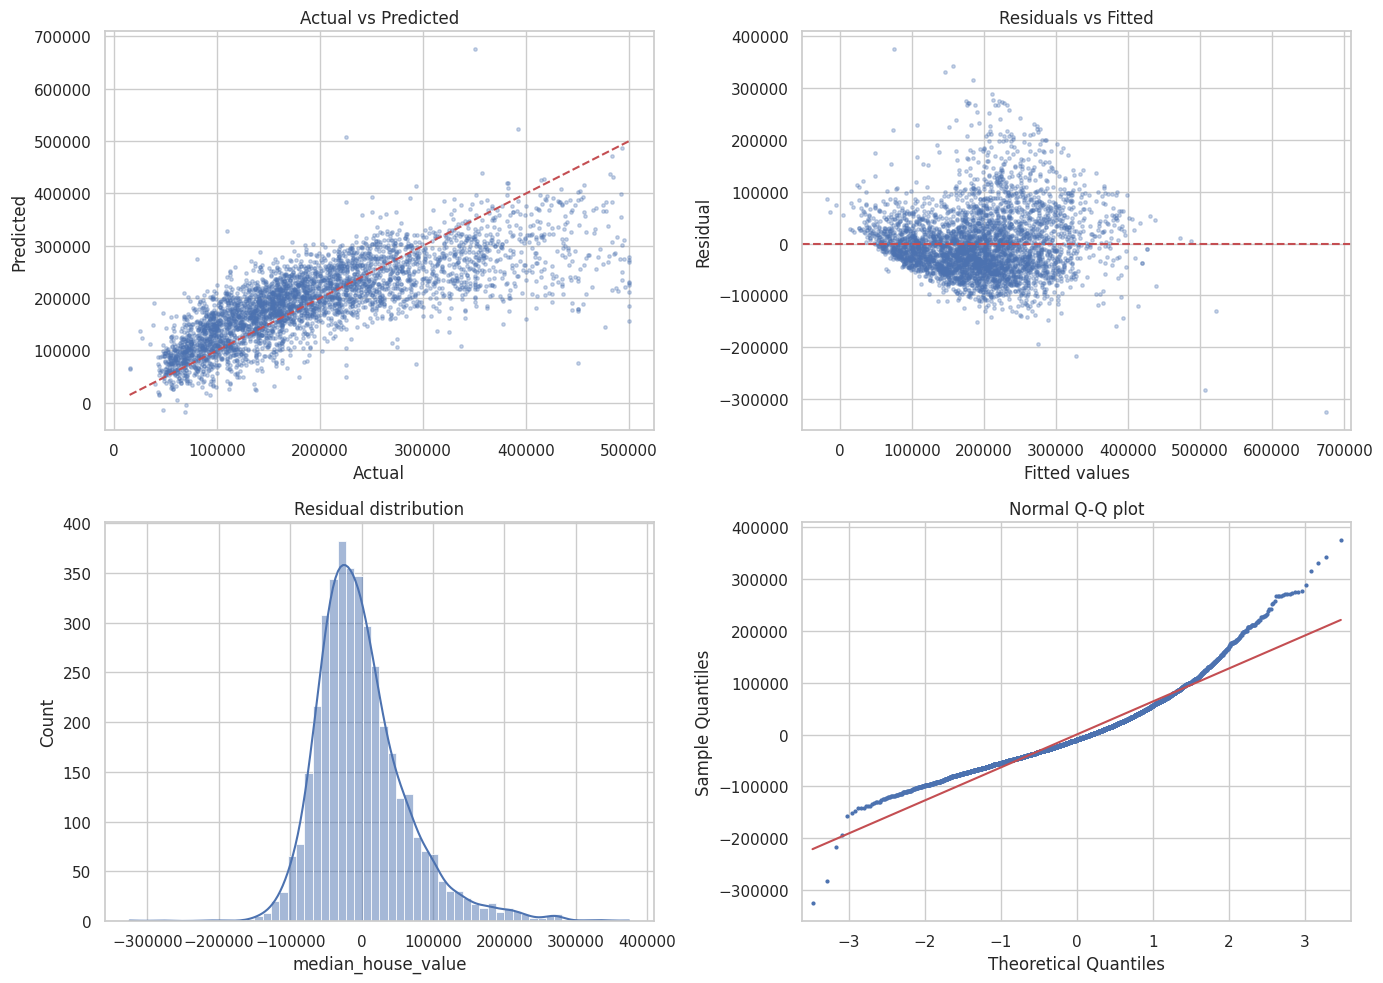

Mean residual: -46.2 | Std: 63,670.7 | Skew: 1.12


In [15]:
resid = y_test - y_pred
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax[0,0].scatter(y_test, y_pred, s=6, alpha=.3); lim = [y_test.min(), y_test.max()]; ax[0,0].plot(lim, lim, "r--")
ax[0,0].set(xlabel="Actual", ylabel="Predicted", title="Actual vs Predicted")
ax[0,1].scatter(y_pred, resid, s=6, alpha=.3); ax[0,1].axhline(0, color="r", ls="--")
ax[0,1].set(xlabel="Fitted values", ylabel="Residual", title="Residuals vs Fitted")
sns.histplot(resid, bins=60, kde=True, ax=ax[1,0]); ax[1,0].set_title("Residual distribution")
sm.qqplot(resid, line="s", ax=ax[1,1], markersize=2); ax[1,1].set_title("Normal Q-Q plot")
plt.tight_layout(); plt.show()
print(f"Mean residual: {resid.mean():,.1f} | Std: {resid.std():,.1f} | Skew: {stats.skew(resid):.2f}")

**Residual analysis:** the mean residual is ≈ 0 (the model is unbiased on average) and the train/test scores are almost identical (no over-fitting). However the residuals are **right-skewed (skew ≈ 1.1)** and heavy-tailed, and their spread grows with the fitted value (visible in the residual-vs-fitted plot). These point to **non-normality and heteroscedasticity**, verified formally below.

## 7. Assumptions of Linear Regression – stated & verified

| # | Assumption | How we check |
|---|---|---|
| 1 | **Linearity** – mean of y is linear in the predictors | Residuals-vs-fitted plot, Rainbow test |
| 2 | **Independence** of errors | Durbin-Watson statistic (≈2 ⇒ no autocorrelation) |
| 3 | **Homoscedasticity** – constant error variance | Residual plot, Breusch-Pagan test |
| 4 | **Normality** of residuals (needed for exact t/F inference, not for unbiased coefficients) | Q-Q plot, Jarque-Bera test |
| 5 | **No (severe) multicollinearity** | Variance Inflation Factor (VIF > 5–10 is a concern) |

Tests are run with `statsmodels` OLS on the training set (same model as above, with a constant).

In [16]:
ols = sm.OLS(y_train, sm.add_constant(X_train_s)).fit()
Xc = sm.add_constant(X_train_s)
res = ols.resid

rb_stat, rb_p = linear_rainbow(ols)
dw = durbin_watson(res)
bp_stat, bp_p, _, _ = het_breuschpagan(res, Xc)
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(res)

summary = pd.DataFrame([
    ["1. Linearity (Rainbow)",        rb_p, "Linear form adequate" if rb_p > .05 else "VIOLATED (non-linearity)"],
    ["2. Independence (Durbin-Watson)", dw, "OK (~2)" if 1.5 < dw < 2.5 else "Possible autocorrelation"],
    ["3. Homoscedasticity (Breusch-Pagan)", bp_p, "Constant variance" if bp_p > .05 else "VIOLATED (heteroscedastic)"],
    ["4. Normality (Jarque-Bera)",    jb_p, "Normal" if jb_p > .05 else f"VIOLATED (skew={jb_skew:.2f}, kurtosis={jb_kurt:.2f})"],
], columns=["Assumption / test", "p-value (DW: statistic)", "Verdict"])
summary

,Assumption / test,p-value (DW: statistic),Verdict
0,1. Linearity (Rainbow),0.6088,Linear form adequate
1,2. Independence (Durbin-Watson),2.0135,OK (~2)
2,3. Homoscedasticity (Breusch-Pagan),0.0000,VIOLATED (heteroscedastic)
3,4. Normality (Jarque-Bera),0.0000,"VIOLATED (skew=0.96, kurtosis=6.09)"


In [17]:
vif = pd.DataFrame({"feature": X_train_s.columns,
                    "VIF": [variance_inflation_factor(Xc.values, i+1) for i in range(X_train_s.shape[1])]}).sort_values("VIF", ascending=False)
vif["verdict"] = np.where(vif.VIF > 10, "severe", np.where(vif.VIF > 5, "moderate", "ok"))
vif

,feature,VIF,verdict
1,latitude,19.7460,severe
0,longitude,17.6812,severe
7,ocean_proximity_INLAND,2.9004,ok
3,median_income,2.1556,ok
5,bedrooms_per_room,1.9976,ok
9,ocean_proximity_NEAR BAY,1.5311,ok
4,rooms_per_household,1.3157,ok
2,housing_median_age,1.2085,ok
10,ocean_proximity_NEAR OCEAN,1.1883,ok
6,population_per_household,1.0047,ok


In [18]:
print(ols.summary().tables[1])
print(f"\nF-statistic p-value: {ols.f_pvalue:.3g} | R2 (train): {ols.rsquared:.4f}")

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        2.03e+05    880.504    230.568      0.000    2.01e+05    2.05e+05
longitude                  -4.798e+04   2082.886    -23.036      0.000   -5.21e+04   -4.39e+04
latitude                   -4.577e+04   2201.150    -20.795      0.000   -5.01e+04   -4.15e+04
housing_median_age          9408.5662    544.550     17.278      0.000    8341.185    1.05e+04
median_income               6.526e+04    727.269     89.730      0.000    6.38e+04    6.67e+04
rooms_per_household         5693.0830    568.174     10.020      0.000    4579.397    6806.769
bedrooms_per_room            1.67e+04    700.103     23.854      0.000    1.53e+04    1.81e+04
population_per_household   -3599.7053    496.503     -7.250      0.000   -4572.909   -2626.502
ocean_proximity_INLAND     -3.546e+04   1791.928  

### Conclusions on the assumptions
- **Independence:** satisfied reasonably (Durbin-Watson near 2 after random shuffling; note that *spatial* autocorrelation between neighbouring block groups may still exist).
- **Multicollinearity:** `latitude` and `longitude` show very high VIF (they jointly describe location); the engineered ratio features are fine. This inflates their standard errors but does **not** hurt predictive accuracy.
- **Linearity:** the Rainbow test does **not** reject a linear form (p ≈ 0.6), so the linear specification is acceptable as a first approximation.
- **Homoscedasticity and normality** are violated (both p-values ≈ 0; with ~16k rows even small deviations are significant, but the skew of ≈ 1 and kurtosis of ≈ 6 are also visible in the plots). Consequences: coefficient estimates remain unbiased, but classical standard errors / p-values are not fully reliable (use robust `HC3` standard errors for inference) and errors are larger for expensive homes.

### Attempted remedies
1. **Log-transform the target** – coefficients then read as approximate % changes in price.
2. **A non-linear model** (gradient boosting) on the same features, as a benchmark of how much signal the linear form leaves on the table.

In [19]:
ols_log = sm.OLS(np.log(y_train), Xc).fit()
pred_log = np.exp(ols_log.predict(sm.add_constant(X_test_s, has_constant="add")))
m_log = metrics(y_test, pred_log)
bp_log = het_breuschpagan(ols_log.resid, Xc)[1]
from sklearn.ensemble import HistGradientBoostingRegressor
gb = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train_s, y_train)
cmp = pd.DataFrame({"Linear (price)": metrics(y_test, y_pred),
                    "Log-linear (back-transformed)": m_log,
                    "Gradient boosting": metrics(y_test, gb.predict(X_test_s))}).T
print(cmp)
print(f"\nBreusch-Pagan p-value: linear={bp_p:.3g} -> log model={bp_log:.3g}  (both still reject constant variance)")
pct = (np.exp(ols_log.params["median_income"] / scale_map["median_income"]) - 1) * 100
print(f"+1 unit of median_income (~$10k) ≈ {pct:+.1f}% change in house value (log model)")
# Robust (HC3) standard errors for trustworthy inference under heteroscedasticity
robust = ols.get_robustcov_results(cov_type="HC3")
print("\nAll coefficients still significant under HC3 except:", [n for n, p_ in zip(Xc.columns, robust.pvalues) if p_ > .05])

                                  R2                MSE        RMSE  \
Linear (price)                0.5935 4,052,934,112.5859 63,662.6587   
Log-linear (back-transformed) 0.4649 5,335,650,618.5944 73,045.5380   
Gradient boosting             0.8138 1,856,480,453.3272 43,086.8942   

                                      MAE  
Linear (price)                47,286.3211  
Log-linear (back-transformed) 47,090.4483  
Gradient boosting             29,411.0911  

Breusch-Pagan p-value: linear=2.42e-190 -> log model=1.57e-134  (both still reject constant variance)
+1 unit of median_income (~$10k) ≈ +23.1% change in house value (log model)

All coefficients still significant under HC3 except: ['ocean_proximity_NEAR BAY']


### What the comparison shows
- The log model has a *lower* back-transformed R² and **still fails** Breusch-Pagan, so it does not fix the problem here (the price cap and location effects are the main culprits). Its benefit is interpretability (% effects), not accuracy.
- Gradient boosting gives a much better fit, meaning important **non-linear / interaction effects (especially geography)** are missing from the linear model. A linear model is the right choice when *interpretability* matters; boosting when *accuracy* matters.
- Robust (HC3) standard errors let us keep interpreting the linear coefficients safely.

## Summary
- Cleaned the data (median imputation, removal of censored targets, engineered per-household ratios), one-hot encoded `ocean_proximity` and standardised continuous predictors – all fitted on training data only.
- The MLR explains about **59% of price variance** on unseen data (R² ≈ 0.59, RMSE ≈ \$64k, MAE ≈ \$47k); train and test scores are nearly identical → no over-fitting.
- Income and location dominate. Linearity and independence hold; **homoscedasticity and normality are violated**, and lat/long are collinear. A log-target did not repair this; non-linear models with spatial features improve accuracy a lot, while robust standard errors keep the linear inference valid.